In [1]:
import os 
import configparser

In [2]:
config_path = "configs/Training_config.ini"
config_read = configparser.ConfigParser()
config_read.read(config_path)

['configs/Training_config.ini']

In [3]:
for sect in config_read.sections():
    print('Title:', sect)
    for k,v in config_read.items(sect):
        print(' {} = {}'.format(k,v))
    print()

Title: TrainingInfo
 traindataset = ['jaadbeh_with_c_g/train/']
 loss = BCE
 save_model_folder_acc = training_results/best_val_acc/
 save_model_folder_f1 = training_results/best_val_f1/
 batch_size = 100
 stratifiedkfold_random_state = 1
 graph_seed = 2676
 1dcnn_seed = 2726



In [4]:
import json
train_folder = json.loads(config_read.get("TrainingInfo", "traindataset").replace("'",'"'))
loss_name = config_read.get("TrainingInfo", "loss")
save_model_folder_acc = config_read.get("TrainingInfo", "save_model_folder_acc")
save_model_folder_f1 = config_read.get("TrainingInfo", "save_model_folder_f1")
batch_size = int(config_read.get("TrainingInfo", "batch_size"))
ran_2 = int(config_read.get("TrainingInfo", "stratifiedkfold_random_state"))

# Load training data

In [5]:
import numpy as np
root = 'preprocessed_data/'+train_folder[0]
x_k_train, y_k_train = np.load(root + 'x_k.npy'), np.load(root + 'y.npy')
x_t_train, y_t_train = np.load(root + 'x_t.npy'), np.load(root + 'y.npy')
x_c_train, y_c_train = np.load(root + 'x_c.npy'), np.load(root + 'y.npy')
x_g_train, y_g_train = np.load(root + 'x_g.npy'), np.load(root + 'y.npy')

In [6]:
y_t = y_t_train
count_pos, count_neg = 0, 0
for label in y_t:
    if label == [1.0]:
        count_pos+=1
    else:
        count_neg+=1
print('Negative class is minority class')
print('Imbalance ratio: {0}:{1}'.format(str(round(count_pos/len(y_t),2)), str(round(count_neg/len(y_t),2))))
print('Number of sample deficit: {0}'.format(str(count_pos-count_neg)))

Negative class is minority class
Imbalance ratio: 0.58:0.42
Number of sample deficit: 3979


# predict each val fold's FC output

In [7]:
from model_evaluation.model_predictions import predict_graph, predict_1dcnn_addfeatures, predict_gru
import numpy as np

In [13]:
from sklearn.model_selection import StratifiedKFold
import torch
def get_val_probs(predict_model, model_folder, X_data, y_data, is_m2 = False, g_data = None, c_data_sizes=None):
    
    if torch.cuda.is_available():
        device = torch.device('cuda')
    else:
        device = torch.device('cpu')
    
    val_preds = []
    val_gts = []
    ensemble_fcs = []
    Stratified_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=ran_2)
    
    for i, (train_index, val_index) in enumerate(Stratified_kfold.split(X_data, y_data)):
        sub_model_folder = model_folder+'fold_{0}/'.format(i+1)
        
        X_val, y_val = X_data[val_index], y_data[val_index]
#         X_val = torch.FloatTensor(X_val).to(device)
        val_gts.append(y_val)
        if not is_m2:
            FC_outputs = predict_model(sub_model_folder, X_val, device, 'f1').cpu().detach()#FC_outputs: outputs of the last FC
        else:
            g_val = g_data[val_index]
            g_data_size = g_val.shape
            FC_outputs = predict_gru(c_data_sizes, g_data_size, sub_model_folder, X_val, g_val, device, 'f1').to('cpu')
        
        probs = torch.sigmoid(FC_outputs)
        preds = torch.round(probs)
        val_preds.append(preds)
        ensemble_fcs.append(FC_outputs)
    return ensemble_fcs, val_preds, val_gts

In [14]:
model_folder = "best_val_f1/"
ensemble_x1, val_preds_x1, val_gts_x1 = get_val_probs(predict_graph, model_folder, x_k_train, y_k_train)
ensemble_x1 = torch.cat(ensemble_x1, axis=0)

/data/home/acw607/reproduce_pip/model_evaluation/model_predictions.py:18: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path)


In [15]:
ensemble_x3, val_preds_x3, val_gts_x3 = get_val_probs(predict_1dcnn_addfeatures, model_folder, x_t_train, y_t_train)
ensemble_x3 = torch.cat(ensemble_x3, axis=0)

/data/home/acw607/reproduce_pip/model_evaluation/model_predictions.py:34: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path)


In [17]:
c_data_sizes = [(16, 1), (16, 1)]
ensemble_x2, val_preds_x2, val_gts_x2 = get_val_probs(predict_gru, model_folder, x_c_train, y_c_train, True, x_g_train, c_data_sizes)
ensemble_x2 = torch.cat(ensemble_x2, axis=0)

torch.Size([4900, 16, 2]) torch.Size([4900, 2])
torch.Size([9800, 16, 1]) torch.Size([4900, 2])
torch.Size([4900, 16, 2]) torch.Size([4900, 2])
torch.Size([9800, 16, 1]) torch.Size([4900, 2])
torch.Size([4900, 16, 2]) torch.Size([4900, 2])
torch.Size([9800, 16, 1]) torch.Size([4900, 2])
torch.Size([4900, 16, 2]) torch.Size([4900, 2])
torch.Size([9800, 16, 1]) torch.Size([4900, 2])
torch.Size([4899, 16, 2]) torch.Size([4899, 2])
torch.Size([9798, 16, 1]) torch.Size([4899, 2])


/data/home/acw607/reproduce_pip/model_evaluation/model_predictions.py:53: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  b = torch.tensor(x2)
/data/home/acw607/reproduce_pip/model_evaluation/model_predictions.py:56: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.s

In [18]:
val_preds_x1 = torch.cat(val_preds_x1, axis=0)
val_preds_x2 = torch.cat(val_preds_x2, axis=0)
val_preds_x3 = torch.cat(val_preds_x3, axis=0)

In [19]:
val_gts_x1 = np.concatenate(val_gts_x1, axis=0)
val_gts_x2 = np.concatenate(val_gts_x2, axis=0)
val_gts_x3 = np.concatenate(val_gts_x3, axis=0)

In [20]:
def acc(preds, targets):
    train_corrects = 0
    train_corrects += (preds == targets).sum().item()
    acc = train_corrects/len(targets)
    return acc

In [24]:
acc(np.array(val_preds_x1), val_gts_x1)

0.8836687211722928

In [25]:
acc(np.array(val_preds_x2.detach().numpy()), val_gts_x2)

0.8352993999755092

In [26]:
acc(np.array(val_preds_x3), val_gts_x3)

0.7652557247234582

# split (FC_output: x1, x2, x3 also called lv1 features) Data again to Train/Val 

In [27]:
import numpy as np
from sklearn.model_selection import train_test_split

In [28]:
ran_3 = 70
test_ratio=0.2
X_train_x1, X_val_x1, y_train_x1, y_val_x1 = train_test_split(ensemble_x1, val_gts_x1, test_size=test_ratio, random_state=ran_3)
X_train_x2, X_val_x2, y_train_x2, y_val_x2 = train_test_split(ensemble_x2, val_gts_x1, test_size=test_ratio, random_state=ran_3)
X_train_x3, X_val_x3, y_train_x3, y_val_x3 = train_test_split(ensemble_x3, val_gts_x1, test_size=test_ratio, random_state=ran_3)

In [29]:
print(X_train_x1.shape, X_train_x2.shape, X_train_x3.shape, y_train_x1.shape)

torch.Size([19599, 1]) torch.Size([19599, 1]) torch.Size([19599, 1]) (19599, 1)


# Train ensemble learning - on lv1 features

In [23]:
# Train/Test: ensemble_probs_x1, ensemble_probs_x2, ensemble_probs_x3
# Test: X_test_k, X_test_s, X_test_t

In [31]:
def count_imbalance(y_t):
    count_pos, count_neg = 0, 0
    for label in y_t:
        if label == [1.0]:
            count_pos+=1
        else:
            count_neg+=1
    if count_pos>count_neg:
        print('Negative class is minority class')
    else:
        print('Positive class is minority class')
        
    print('Imbalance ratio: {0}:{1}'.format(str(round(count_pos/len(y_t),2)), str(round(count_neg/len(y_t),2))))
    print('Number of sample deficit: {0}'.format(str(abs(count_pos-count_neg))))
    return count_pos/(count_pos+count_neg)

alpha = count_imbalance(y_train_x1)

Negative class is minority class
Imbalance ratio: 0.58:0.42
Number of sample deficit: 3151


In [32]:
import os
import torch 
import numpy as np
import utils.data_loader as Dataset
from torch.utils.data import DataLoader
import models.ensemble as EN
# import models.onedcnn_model_second as onedcnn_model_second
# torch.backends.cudnn.enabled=False

In [33]:
save_model_folder_acc, save_model_folder_f1 = 'training_results/best_val_acc/aggregate/', 'training_results/best_val_f1/aggregate/'


if not os.path.exists(save_model_folder_acc):
    os.mkdir(save_model_folder_acc)

if not os.path.exists(save_model_folder_f1):
    os.mkdir(save_model_folder_f1)

In [34]:
from torch.utils.data import Dataset, DataLoader
class leveloneData_ensemble(Dataset):
    
    def __init__(self, X_data, y_data):
        self.X_data = X_data
        self.y_data = y_data
        
    def __getitem__(self, index):
        return self.X_data[index], self.y_data[index]
        
    def __len__ (self):
        return len(self.X_data)

Dataloader seed: 2726
[INFO]: Epoch 2 of 200
Training loss: 1.528, training acc: 18.000
Validation loss: 1.115, validation acc: 24.000
--------------------------------------------------

Best validation acc: 24.0

Saving best model for epoch: 2


Best validation f1: 0.25

Saving best model for epoch: 2

[INFO]: Epoch 3 of 200
Training loss: 0.828, training acc: 34.000
Validation loss: 0.600, validation acc: 45.000
--------------------------------------------------

Best validation acc: 45.0

Saving best model for epoch: 3


Best validation f1: 0.45

Saving best model for epoch: 3

[INFO]: Epoch 4 of 200
Training loss: 0.466, training acc: 59.000
Validation loss: 0.365, validation acc: 70.000
--------------------------------------------------

Best validation acc: 70.0

Saving best model for epoch: 4


Best validation f1: 0.69

Saving best model for epoch: 4

[INFO]: Epoch 5 of 200
Training loss: 0.306, training acc: 77.000
Validation loss: 0.262, validation acc: 81.000
----------------

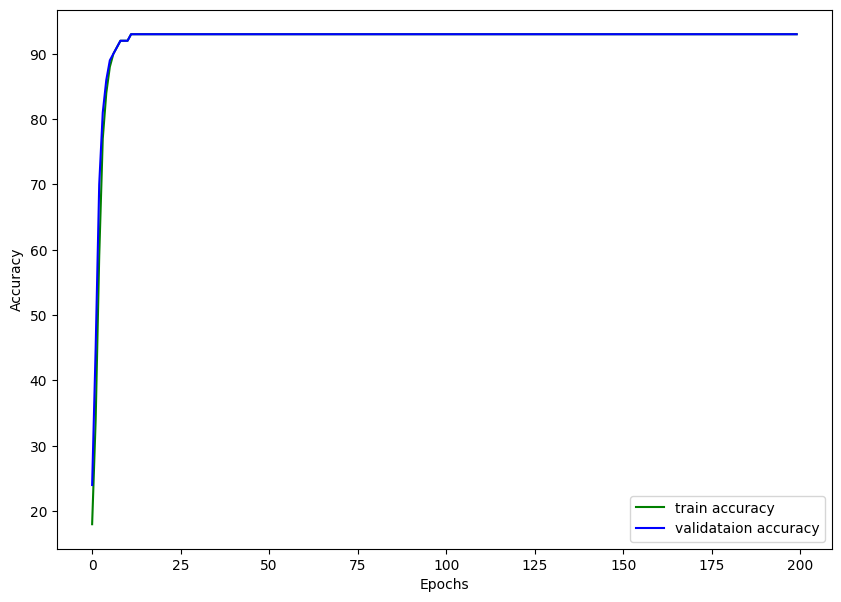

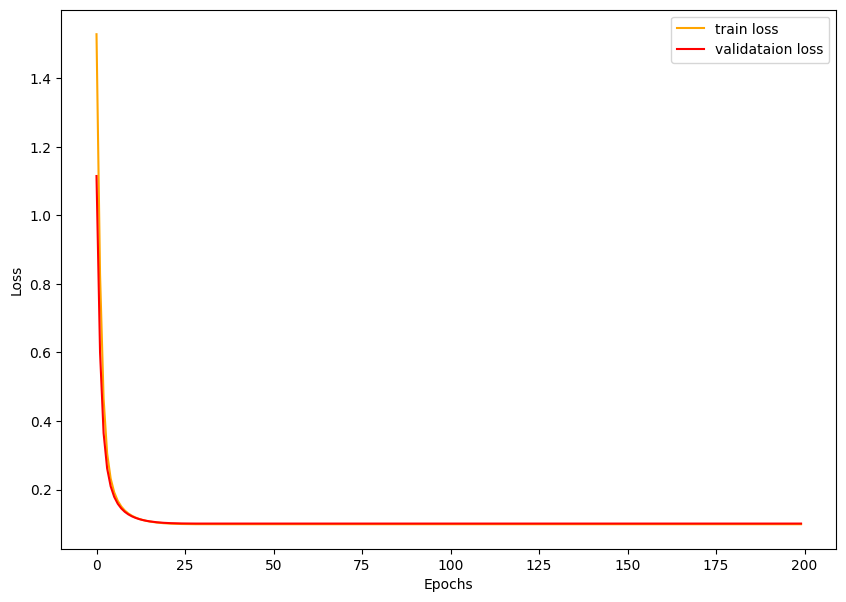

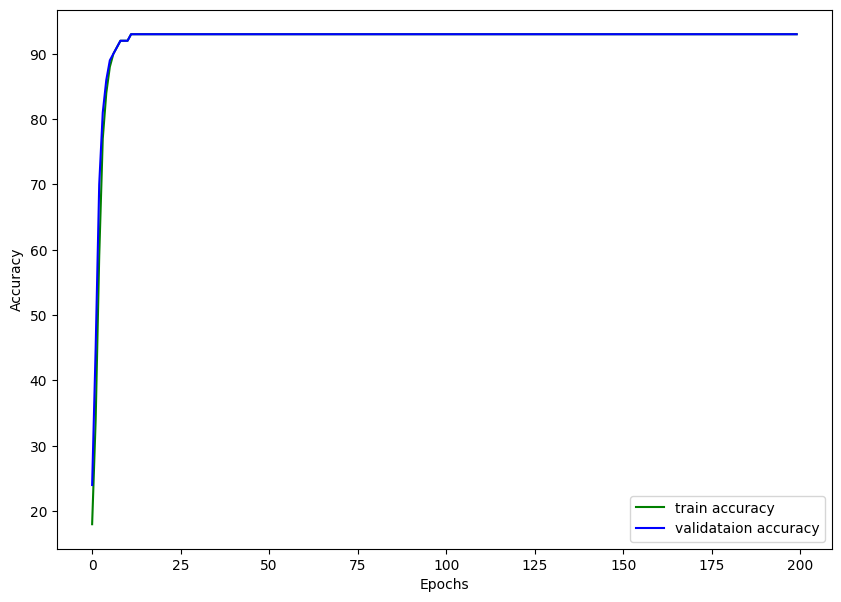

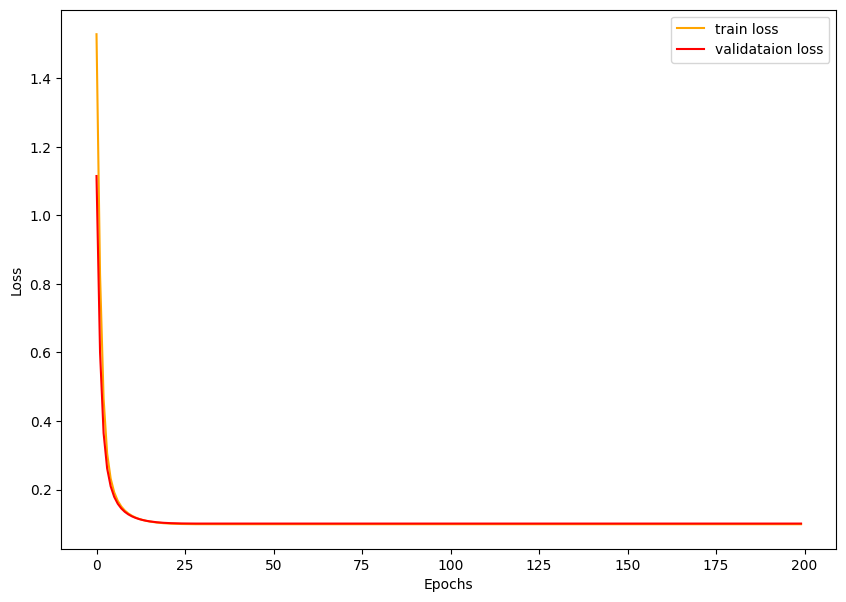

In [35]:
# torch.backends.cudnn.enabled = False
X_train = torch.concat((torch.FloatTensor(X_train_x1.detach()),torch.FloatTensor(X_train_x2.detach()), torch.FloatTensor(X_train_x3.detach())), dim=1)
X_val = torch.concat((torch.FloatTensor(X_val_x1.detach()),torch.FloatTensor(X_val_x2.detach()),torch.FloatTensor(X_val_x3.detach())), dim=1)
y_train =  torch.FloatTensor(y_train_x1)
y_val =  torch.FloatTensor(y_val_x1)

train_data = leveloneData_ensemble(X_train, y_train_x1)
val_data = leveloneData_ensemble(X_val,  y_val_x1)

train_loader = DataLoader(dataset=train_data, batch_size=batch_size, shuffle=True,drop_last=True)
val_loader = DataLoader(dataset=val_data, batch_size=batch_size, drop_last=True)

EN.train_perceptron_aggregate(train_loader, val_loader, save_model_folder_acc, save_model_folder_f1, loss_name, alpha)

# Test on testset
* (1) we have 5-fold models in each pipeline model (i.e, Graph, GRU, 1dcnn)
* (2) we predict FC_output for our X_test using all 5x3pipelines models.
* (3) we multiply y_test for 5 times as well to match number of samples in (2)
* (4) from (2) we collect ensemble_x and from (3) we collect new y_test
* (5) we test ensemble learner on ensemble_x and calculate its performance stats by comparing ground truth labels new y_test

In [41]:
def get_test_prob(predict_model, model_folder, X_test, is_m2 = False, g_data = None, c_data_sizes=None):
    folds = 5
    ensemble_test = []
    
    if torch.cuda.is_available():
        device = torch.device('cuda')
    else:
        device = torch.device('cpu')   
    for i in range(folds):
        sub_model_folder = model_folder+'fold_{0}/'.format(i+1)
        if not is_m2:
            FC_outputs = predict_model(sub_model_folder, X_test, device, 'f1').cpu().detach()
        else:
            g_data_size = g_data.shape
            FC_outputs = predict_gru(c_data_sizes, g_data_size, sub_model_folder, X_test, g_data, device, 'f1').to('cpu').detach()
        ensemble_test.append(FC_outputs)
    return ensemble_test
    

In [38]:
import numpy as np
root = 'preprocessed_data/jaadbeh_with_c_g/test/'
x_k_test, y_k_test = np.load(root + 'x_k.npy'), np.load(root + 'y.npy')
x_t_test, y_t_test = np.load(root + 'x_t.npy'), np.load(root + 'y.npy')
x_c_test, y_c_test = np.load(root + 'x_c.npy'), np.load(root + 'y.npy')
x_g_test, y_g_test = np.load(root + 'x_g.npy'), np.load(root + 'y.npy')

In [39]:
model_folder = 'best_val_f1/'

In [42]:
import torch
c_data_sizes = [(16, 1), (16, 1)]
ensemble_test_k=get_test_prob(predict_graph, model_folder, x_k_test)
ensemble_test_s=get_test_prob(predict_gru, model_folder, x_c_test, True, x_g_test, c_data_sizes)
ensemble_test_t=get_test_prob(predict_1dcnn_addfeatures, model_folder, x_t_test)

torch.Size([18790, 16, 2]) torch.Size([18790, 2])
torch.Size([37580, 16, 1]) torch.Size([18790, 2])
torch.Size([18790, 16, 2]) torch.Size([18790, 2])
torch.Size([37580, 16, 1]) torch.Size([18790, 2])
torch.Size([18790, 16, 2]) torch.Size([18790, 2])
torch.Size([37580, 16, 1]) torch.Size([18790, 2])
torch.Size([18790, 16, 2]) torch.Size([18790, 2])
torch.Size([37580, 16, 1]) torch.Size([18790, 2])
torch.Size([18790, 16, 2]) torch.Size([18790, 2])
torch.Size([37580, 16, 1]) torch.Size([18790, 2])


/data/home/acw607/reproduce_pip/model_evaluation/model_predictions.py:53: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  b = torch.tensor(x2)
/data/home/acw607/reproduce_pip/model_evaluation/model_predictions.py:56: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.s

In [43]:
ensemble_test_k = np.concatenate(ensemble_test_k,axis=0)
ensemble_test_s = np.concatenate(ensemble_test_s,axis=0)
ensemble_test_t = np.concatenate(ensemble_test_t,axis=0)
ensemble_x_test = np.concatenate([ensemble_test_k, ensemble_test_s, ensemble_test_t], axis=1)
print(ensemble_x_test.shape)

(93950, 3)


In [44]:
# ensemble_x_test.cpu()

In [45]:
y_test = np.concatenate([y_k_test]*5, axis=0)
y_test.shape

(93950, 1)

In [46]:
# preds.device, y_test.device, probs.device

# Predict ensemble aggregate

In [47]:
def predict_ensemble_aggregate(models_folder, x, device, best_by):
    model_root = 'training_results/'+models_folder+'aggregate/'
    if not best_by:
        model_path = model_root+'best_aggregate_model.pth'
    else:
        model_path = model_root+'best_aggregate_model_{0}.pth'.format('by'+best_by)
    print(model_path)
    model = EN.Aggregate().to(device)
    x = torch.FloatTensor(x).to(device)
    checkpoint = torch.load(model_path)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    y_hat = model(x)
    return y_hat 

In [48]:
ensemble_x_test

array([[-4.548328  ,  1.9096997 ,  1.6166595 ],
       [-2.5662546 ,  1.7758386 ,  1.6398027 ],
       [ 0.068212  ,  1.6886694 ,  1.6458519 ],
       ...,
       [ 2.4327102 , -0.81417316,  1.1484586 ],
       [ 1.2508698 , -0.81417316,  1.1218592 ],
       [-2.3900526 , -0.81417316,  1.0896158 ]], dtype=float32)

In [49]:
def acc(preds, targets):
    train_corrects = 0
    train_corrects += (preds == targets).sum().item()
    acc = train_corrects/len(targets)
    return acc

# macro

training_results/best_val_f1/aggregate/best_aggregate_model_byf1.pth
fp_rate: 0.23
fn_rate: 0.44
acc: 0.65
auc: 0.73
f1: 0.65
pr: 0.67
re: 0.66
Confusion martrix: 


/tmp/ipykernel_3360900/2943746638.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  ensemble_x_test = torch.tensor(ensemble_x_test)
/tmp/ipykernel_3360900/2237522226.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We reco

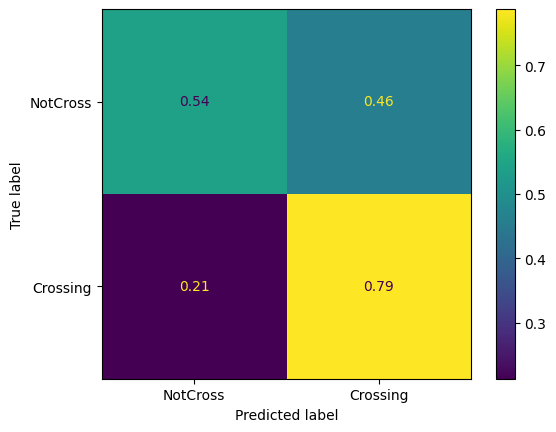

In [52]:
# from model_evaluation.model_predictions import predict_ensemble_aggregate
import models.ensemble as EN
from model_evaluation.performance_scores import get_precision_recall_F1, calculate_acc
from sklearn import metrics
import matplotlib.pyplot as plt
if torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')
ensemble_x_test = torch.tensor(ensemble_x_test)
FC_outputs = predict_ensemble_aggregate(model_folder, ensemble_x_test.cpu(), device, 'f1').cpu().detach()      
probs = torch.sigmoid(FC_outputs)
preds = torch.round(probs)

tn, fp, fn, tp = metrics.confusion_matrix(preds.cpu(), y_test).ravel()
fp_rate = fp/(fp+tn)
fn_rate = fn/(fn+tp) 
test_acc = acc(np.array(preds),y_test)
# y_test = torch.tensor(y_test).to(device)
# probs, preds, y_test = probs.to(device), preds.to(device), y_test.to(device)

p, r, f1, auc = get_precision_recall_F1(preds, y_test, probs)
        
print('fp_rate: {0:.2f}'.format(fp_rate))
print('fn_rate: {0:.2f}'.format(fn_rate))
print('acc: {0:.2f}'.format(test_acc))
print('auc: {0:.2f}'.format(float(auc)))
print('f1: {0:.2f}'.format(float(f1)))
print('pr: {0:.2f}'.format(float(p)))
print('re: {0:.2f}'.format(float(r)))
print('Confusion martrix: ')
# preds = preds.astype(int)
preds_li = np.squeeze(preds).tolist()
confusion_matrix = metrics.confusion_matrix(y_test,preds, normalize='true')
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = ['NotCross', 'Crossing'])
cm_display.plot()
plt.show()


In [56]:
probs_li = probs.tolist()
y_li = y_test.tolist()

import json
with open('JAADbeh_results.json', 'r') as f:
    results = json.load(f)

results['x1_x2_x3'] = {'probs':probs_li, 'preds': preds_li, 'test_gts': y_li}


In [57]:
results.keys()

dict_keys(['x3', 'x1', 'x2', 'x1_x2', 'x1_x3', 'x2_x3', 'x1_x2_x3'])

In [58]:
with open('JAADbeh_results.json', 'w') as f:
    json.dump(results, f)